# Manual Multiclass Linear SVM for MNIST

This notebook implements Phase 2 of the SVM-only MNIST project: a manual multiclass Linear SVM for all ten MNIST classes. The model is written with NumPy and uses the Crammer-Singer multiclass hinge loss.

The notebook is designed to complement the Phase 1 binary SVM notebook. It keeps the SVM implementation manual, while using helper libraries for data loading, feature extraction, preprocessing, plotting, and metrics.


## Phase 2 Goals

The project description asks Phase 2 to scale image classification to ten classes and apply improvement strategies. This notebook keeps the classifier as a manual Linear SVM and adds three SVM-compatible improvements:

1. Hyperparameter tuning with cross-validation.
2. L2 regularization and bias-variance analysis through the SVM penalty parameter C.
3. Overfitting and underfitting diagnosis with learning curves.

The evaluated feature pipelines are flattened pixels, PCA features, and HOG descriptors.


## Mathematical Formulation

For each image $x$, the feature pipeline produces $\phi(x) \in \mathbb{R}^d$. The multiclass Linear SVM learns one weight vector per class. With $K = 10$ classes, the score for class $k$ is:

$$s_k(x) = w_k^T \phi(x) + b_k$$

The prediction rule is:

$$\hat{y} = \arg\max_k s_k(x)$$

For a sample $(x_i, y_i)$, the Crammer-Singer multiclass hinge loss is:

$$L_i = \sum_{k \neq y_i} \max(0, s_k(x_i) - s_{y_i}(x_i) + \Delta)$$

The optimized objective is:

$$J(W, b) = \frac{1}{2} \|W\|_F^2 + C \frac{1}{N} \sum_{i=1}^N L_i$$

The first term is L2 regularization. Larger C penalizes classification errors more strongly; smaller C increases regularization.


In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    import tensorflow as tf
except ImportError:
    tf = None

from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from skimage.feature import hog  # pyright: ignore[reportMissingModuleSource]

SEED = 42
np.random.seed(SEED)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
plt.style.use("seaborn-v0_8-whitegrid")


def find_project_root():
    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "README.md").exists() and (candidate / "Binary Classification").exists():
            return candidate
    return current


PROJECT_ROOT = find_project_root()
OUTPUT_DIR = PROJECT_ROOT / "Multiclass Classification" / "LinearSVM" / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

CLASS_LABELS = np.arange(10)
CLASS_NAMES = [str(label) for label in CLASS_LABELS]

# These stratified limits keep the manual SVM notebook practical to run locally.
# Set all three to None if you want a full-MNIST run.
MAX_TRAIN_SAMPLES = None
MAX_VAL_SAMPLES = None
MAX_TEST_SAMPLES = None


## Data Loading and Splitting

The loader first tries TensorFlow's bundled MNIST loader. If TensorFlow is unavailable, it falls back to OpenML through scikit-learn. Images are normalized to [0, 1], and the split is stratified so each digit remains represented in train, validation, and test sets. The default notebook run uses a stratified subset to keep the manual SVM experiments practical; set the sample-limit constants to None for a full-MNIST run.


In [2]:
def load_mnist_multiclass():
    if tf is not None:
        (x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
        x_train = x_train.astype(np.float32) / 255.0
        x_test = x_test.astype(np.float32) / 255.0
        y_train = y_train.astype(np.int64)
        y_test = y_test.astype(np.int64)
        return x_train, x_test, y_train, y_test

    X, y = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)
    X = X.astype(np.float32).reshape(-1, 28, 28) / 255.0
    y = y.astype(np.int64)
    x_train, x_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=10000,
        random_state=SEED,
        stratify=y,
    )
    return x_train, x_test, y_train, y_test


def stratified_subset(X, y, max_samples=None, random_state=SEED):
    if max_samples is None or max_samples >= len(y):
        return X, y
    _, X_subset, _, y_subset = train_test_split(
        X,
        y,
        test_size=max_samples,
        random_state=random_state,
        stratify=y,
    )
    return X_subset, y_subset


def summarize_multiclass_split(name, y):
    counts = np.bincount(y, minlength=10)
    row = {"split": name, "samples": int(len(y))}
    row.update({f"digit_{digit}": int(counts[digit]) for digit in CLASS_LABELS})
    return row


x_train_full, x_test, y_train_full, y_test = load_mnist_multiclass()
x_train, x_val, y_train, y_val = train_test_split(
    x_train_full,
    y_train_full,
    test_size=0.2,
    random_state=SEED,
    stratify=y_train_full,
)

x_train, y_train = stratified_subset(x_train, y_train, MAX_TRAIN_SAMPLES, random_state=SEED)
x_val, y_val = stratified_subset(x_val, y_val, MAX_VAL_SAMPLES, random_state=SEED + 1)
x_test, y_test = stratified_subset(x_test, y_test, MAX_TEST_SAMPLES, random_state=SEED + 2)

split_data = {
    "x_train": x_train,
    "y_train": y_train,
    "x_val": x_val,
    "y_val": y_val,
    "x_test": x_test,
    "y_test": y_test,
}

split_summary = pd.DataFrame([
    summarize_multiclass_split("train", y_train),
    summarize_multiclass_split("validation", y_val),
    summarize_multiclass_split("test", y_test),
])
split_summary


,split,samples,digit_0,digit_1,digit_2,digit_3,digit_4,digit_5,digit_6,digit_7,digit_8,digit_9
0,train,12000,1184,1348,1192,1226,1169,1084,1184,1253,1170,1190
1,validation,3000,296,337,298,307,292,271,296,313,293,297
2,test,3000,294,340,310,303,295,268,287,308,292,303


## Feature Pipelines

Three feature pipelines are tested:

1. Flattened pixels: 28 x 28 images become 784-dimensional vectors.
2. PCA features: flattened pixels are projected into a lower-dimensional PCA space fitted only on the training split.
3. HOG features: gradient-orientation descriptors capture local shape information.

Every scaler and PCA transformer is fitted only on the training split to prevent data leakage.


In [3]:
def flatten_features(X):
    return X.reshape(X.shape[0], -1).astype(np.float32)


def fit_pca(X_train, n_components=100):
    pca = PCA(n_components=n_components, random_state=SEED)
    pca.fit(flatten_features(X_train))
    return pca


def transform_pca(X, pca_state):
    return pca_state.transform(flatten_features(X)).astype(np.float32)


def hog_features(X, orientations=9, pixels_per_cell=(4, 4), cells_per_block=(2, 2)):
    descriptors = [
        hog(
            image,
            orientations=orientations,
            pixels_per_cell=pixels_per_cell,
            cells_per_block=cells_per_block,
            block_norm="L2-Hys",
            feature_vector=True,
        )
        for image in X
    ]
    return np.vstack(descriptors).astype(np.float32)


def prepare_feature_set(feature_mode, split_data, pca_components=100):
    if feature_mode == "flatten":
        x_train_features = flatten_features(split_data["x_train"])
        x_val_features = flatten_features(split_data["x_val"])
        x_test_features = flatten_features(split_data["x_test"])
        metadata = {"feature_mode": feature_mode}
    elif feature_mode == "pca":
        pca_state = fit_pca(split_data["x_train"], n_components=pca_components)
        x_train_features = transform_pca(split_data["x_train"], pca_state)
        x_val_features = transform_pca(split_data["x_val"], pca_state)
        x_test_features = transform_pca(split_data["x_test"], pca_state)
        metadata = {
            "feature_mode": feature_mode,
            "pca_components": int(pca_state.n_components_),
            "explained_variance_ratio": float(np.sum(pca_state.explained_variance_ratio_)),
        }
    elif feature_mode == "hog":
        x_train_features = hog_features(split_data["x_train"])
        x_val_features = hog_features(split_data["x_val"])
        x_test_features = hog_features(split_data["x_test"])
        metadata = {
            "feature_mode": feature_mode,
            "orientations": 9,
            "pixels_per_cell": (4, 4),
            "cells_per_block": (2, 2),
        }
    else:
        raise ValueError(f"Unsupported feature_mode: {feature_mode}")

    scaler = StandardScaler()
    x_train_features = scaler.fit_transform(x_train_features).astype(np.float32)
    x_val_features = scaler.transform(x_val_features).astype(np.float32)
    x_test_features = scaler.transform(x_test_features).astype(np.float32)

    features = {
        "x_train": x_train_features,
        "x_val": x_val_features,
        "x_test": x_test_features,
    }
    metadata["feature_dimension"] = int(x_train_features.shape[1])
    return features, metadata


## Manual Multiclass Linear SVM

The model below performs mini-batch subgradient descent on the multiclass hinge objective. The gradient is vectorized over the batch: incorrect classes with positive margins receive positive gradient contribution, while the correct class receives the negative row sum.


In [4]:
class ManualMulticlassLinearSVM:
    def __init__(self, C=1.0, epochs=15, batch_size=256, lr=0.01, lr_decay=0.95, delta=1.0, num_classes=None, random_state=SEED):
        self.C = C
        self.epochs = epochs
        self.batch_size = batch_size
        self.lr = lr
        self.lr_decay = lr_decay
        self.delta = delta
        self.num_classes = num_classes
        self.random_state = random_state
        self.W = None
        self.b = None
        self.history = []

    def _objective(self, X, y):
        import numpy as np
        scores = X @ self.W + self.b
        correct_scores = scores[np.arange(len(y)), y][:, None]
        margins = np.maximum(0.0, scores - correct_scores + self.delta)
        margins[np.arange(len(y)), y] = 0.0
        data_loss = np.mean(np.sum(margins, axis=1))
        reg_loss = 0.5 * np.sum(self.W * self.W)
        return float(reg_loss + self.C * data_loss)

    def fit(self, X_train, y_train, X_val=None, y_val=None):
        import numpy as np
        X_train = np.asarray(X_train, dtype=np.float32)
        y_train = np.asarray(y_train, dtype=np.int64)
        num_samples, num_features = X_train.shape
        num_classes = self.num_classes if self.num_classes is not None else int(np.max(y_train)) + 1

        rng = np.random.default_rng(self.random_state)
        self.W = rng.normal(0.0, 0.001, size=(num_features, num_classes)).astype(np.float32)
        self.b = np.zeros(num_classes, dtype=np.float32)
        current_lr = self.lr
        self.history = []

        m_W = np.zeros_like(self.W)
        v_W = np.zeros_like(self.W)
        m_b = np.zeros_like(self.b)
        v_b = np.zeros_like(self.b)
        beta1, beta2, epsilon = 0.9, 0.999, 1e-8
        t = 0

        best_val_loss = float('inf')
        patience = 5
        patience_counter = 0
        best_W = None
        best_b = None

        for epoch in range(self.epochs):
            indices = rng.permutation(num_samples)
            for start in range(0, num_samples, self.batch_size):
                batch_idx = indices[start:start + self.batch_size]
                X_batch = X_train[batch_idx]
                y_batch = y_train[batch_idx]
                batch_size_act = len(batch_idx)

                scores = X_batch @ self.W + self.b
                correct_scores = scores[np.arange(batch_size_act), y_batch][:, None]
                margins = scores - correct_scores + self.delta
                margins[np.arange(batch_size_act), y_batch] = 0.0
                active = margins > 0.0

                coeff = active.astype(np.float32)
                row_sum = np.sum(coeff, axis=1)
                coeff[np.arange(batch_size_act), y_batch] -= row_sum

                grad_W = self.W + (self.C / batch_size_act) * (X_batch.T @ coeff)
                grad_b = (self.C / batch_size_act) * np.sum(coeff, axis=0)

                t += 1
                m_W = beta1 * m_W + (1 - beta1) * grad_W
                v_W = beta2 * v_W + (1 - beta2) * (grad_W ** 2)
                m_b = beta1 * m_b + (1 - beta1) * grad_b
                v_b = beta2 * v_b + (1 - beta2) * (grad_b ** 2)

                m_W_hat = m_W / (1 - beta1 ** t)
                v_W_hat = v_W / (1 - beta2 ** t)
                m_b_hat = m_b / (1 - beta1 ** t)
                v_b_hat = v_b / (1 - beta2 ** t)

                self.W -= current_lr * m_W_hat / (np.sqrt(v_W_hat) + epsilon)
                self.b -= current_lr * m_b_hat / (np.sqrt(v_b_hat) + epsilon)

            history_row = {
                "epoch": epoch + 1,
                "train_loss": self._objective(X_train, y_train),
                "train_accuracy": float(np.mean(y_train == self.predict(X_train))),
            }
            if X_val is not None and y_val is not None:
                y_val = np.asarray(y_val, dtype=np.int64)
                val_pred = self.predict(X_val)
                history_row["val_loss"] = self._objective(X_val, y_val)
                history_row["val_accuracy"] = float(np.mean(y_val == val_pred))
                
                if history_row["val_loss"] < best_val_loss:
                    best_val_loss = history_row["val_loss"]
                    best_W = self.W.copy()
                    best_b = self.b.copy()
                    patience_counter = 0
                else:
                    patience_counter += 1

            self.history.append(history_row)
            current_lr *= self.lr_decay
            
            if patience_counter >= patience:
                break

        if best_W is not None:
            self.W = best_W
            self.b = best_b

        return self

    def decision_function(self, X):
        import numpy as np
        X = np.asarray(X, dtype=np.float32)
        return X @ self.W + self.b

    def predict(self, X):
        import numpy as np
        return np.argmax(self.decision_function(X), axis=1).astype(np.int64)

## Experiment Helpers

The helper functions run one configuration, summarize metrics, and support compact cross-validation over the hyperparameter grid.


In [5]:
def multiclass_report(y_true, y_pred):
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision_macro": float(precision_score(y_true, y_pred, average="macro", zero_division=0)),
        "recall_macro": float(recall_score(y_true, y_pred, average="macro", zero_division=0)),
        "f1_macro": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "precision_weighted": float(precision_score(y_true, y_pred, average="weighted", zero_division=0)),
        "recall_weighted": float(recall_score(y_true, y_pred, average="weighted", zero_division=0)),
        "f1_weighted": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
    }


def run_experiment(config, split_data):
    features, metadata = prepare_feature_set(
        config["feature_mode"],
        split_data,
        pca_components=config.get("pca_components", 100),
    )
    model = ManualMulticlassLinearSVM(
        C=config.get("C", 1.0),
        epochs=config.get("epochs", 15),
        batch_size=config.get("batch_size", 256),
        lr=config.get("lr", 0.01),
        lr_decay=config.get("lr_decay", 0.95),
        num_classes=len(CLASS_LABELS),
        random_state=config.get("random_state", SEED),
    )
    model.fit(features["x_train"], split_data["y_train"], features["x_val"], split_data["y_val"])

    predictions = {}
    reports = {}
    for split_name in ("train", "val", "test"):
        predictions[split_name] = model.predict(features[f"x_{split_name}"])
        reports[split_name] = multiclass_report(split_data[f"y_{split_name}"], predictions[split_name])

    return {
        "config": config,
        "feature_metadata": metadata,
        "model": model,
        "history": pd.DataFrame(model.history),
        "predictions": predictions,
        "reports": reports,
        "confusion_matrix": confusion_matrix(split_data["y_test"], predictions["test"], labels=CLASS_LABELS),
        "features": features,
    }


def summarize_experiment(name, result):
    row = {
        "name": name,
        "feature_mode": result["config"]["feature_mode"],
        "feature_dimension": result["feature_metadata"]["feature_dimension"],
        "C": result["config"].get("C", 1.0),
        "lr": result["config"].get("lr", 0.01),
        "epochs": result["config"].get("epochs", 15),
        "pca_components": result["config"].get("pca_components", np.nan),
    }
    for split_name in ("train", "val", "test"):
        for metric_name, metric_value in result["reports"][split_name].items():
            row[f"{split_name}_{metric_name}"] = metric_value
    return row


## Hyperparameter Tuning with Cross-Validation

The grid is intentionally compact because the SVM implementation is manual. Cross-validation is performed on a stratified subset of the training data to compare settings fairly without making the notebook unnecessarily slow.


In [6]:
CV_SAMPLE_SIZE = min(9000, len(y_train))
CV_EPOCHS = 8
CV_SPLITS = 3

cv_x, cv_y = stratified_subset(split_data["x_train"], split_data["y_train"], CV_SAMPLE_SIZE, random_state=SEED + 10)

param_grid = [
    {"feature_mode": "flatten", "C": 0.1, "lr": 0.01, "epochs": CV_EPOCHS, "batch_size": 256},
    {"feature_mode": "flatten", "C": 1.0, "lr": 0.01, "epochs": CV_EPOCHS, "batch_size": 256},
    {"feature_mode": "pca", "pca_components": 50, "C": 0.1, "lr": 0.02, "epochs": CV_EPOCHS, "batch_size": 256},
    {"feature_mode": "pca", "pca_components": 100, "C": 1.0, "lr": 0.02, "epochs": CV_EPOCHS, "batch_size": 256},
    {"feature_mode": "hog", "C": 0.1, "lr": 0.02, "epochs": CV_EPOCHS, "batch_size": 256},
    {"feature_mode": "hog", "C": 1.0, "lr": 0.02, "epochs": CV_EPOCHS, "batch_size": 256},
]


def cross_validate_config(config, X, y, n_splits=CV_SPLITS):
    splitter = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    fold_rows = []
    for fold, (train_idx, val_idx) in enumerate(splitter.split(X, y), start=1):
        fold_split = {
            "x_train": X[train_idx],
            "y_train": y[train_idx],
            "x_val": X[val_idx],
            "y_val": y[val_idx],
            "x_test": X[val_idx],
            "y_test": y[val_idx],
        }
        result = run_experiment(config, fold_split)
        fold_rows.append({
            "fold": fold,
            "val_accuracy": result["reports"]["val"]["accuracy"],
            "val_macro_f1": result["reports"]["val"]["f1_macro"],
            "val_weighted_f1": result["reports"]["val"]["f1_weighted"],
        })
    return pd.DataFrame(fold_rows)


cv_rows = []
cv_details = {}
for config_id, config in enumerate(param_grid, start=1):
    print(f"Running CV config {config_id}/{len(param_grid)}: {config}")
    fold_table = cross_validate_config(config, cv_x, cv_y)
    cv_details[config_id] = fold_table
    cv_rows.append({
        "config_id": config_id,
        "feature_mode": config["feature_mode"],
        "pca_components": config.get("pca_components", np.nan),
        "C": config["C"],
        "lr": config["lr"],
        "epochs": config["epochs"],
        "mean_val_accuracy": fold_table["val_accuracy"].mean(),
        "std_val_accuracy": fold_table["val_accuracy"].std(),
        "mean_val_macro_f1": fold_table["val_macro_f1"].mean(),
        "std_val_macro_f1": fold_table["val_macro_f1"].std(),
        "mean_val_weighted_f1": fold_table["val_weighted_f1"].mean(),
    })

cv_results = pd.DataFrame(cv_rows).sort_values("mean_val_macro_f1", ascending=False).reset_index(drop=True)
best_cv_config_id = int(cv_results.iloc[0]["config_id"])
best_cv_config = dict(param_grid[best_cv_config_id - 1])
cv_results


Running CV config 1/6: {'feature_mode': 'flatten', 'C': 0.1, 'lr': 0.01, 'epochs': 8, 'batch_size': 256}


Running CV config 2/6: {'feature_mode': 'flatten', 'C': 1.0, 'lr': 0.01, 'epochs': 8, 'batch_size': 256}


Running CV config 3/6: {'feature_mode': 'pca', 'pca_components': 50, 'C': 0.1, 'lr': 0.02, 'epochs': 8, 'batch_size': 256}


Running CV config 4/6: {'feature_mode': 'pca', 'pca_components': 100, 'C': 1.0, 'lr': 0.02, 'epochs': 8, 'batch_size': 256}


Running CV config 5/6: {'feature_mode': 'hog', 'C': 0.1, 'lr': 0.02, 'epochs': 8, 'batch_size': 256}


Running CV config 6/6: {'feature_mode': 'hog', 'C': 1.0, 'lr': 0.02, 'epochs': 8, 'batch_size': 256}


,config_id,feature_mode,pca_components,C,lr,epochs,mean_val_accuracy,std_val_accuracy,mean_val_macro_f1,std_val_macro_f1,mean_val_weighted_f1
0,6,hog,NaN,1.0,0.02,8,0.962889,0.001678,0.962655,0.001845,0.962864
1,5,hog,NaN,0.1,0.02,8,0.954444,0.003717,0.954227,0.003773,0.954413
2,2,flatten,NaN,1.0,0.01,8,0.885889,0.001953,0.884058,0.002100,0.885289
3,4,pca,100.0,1.0,0.02,8,0.862778,0.000694,0.860951,0.000494,0.862494
4,1,flatten,NaN,0.1,0.01,8,0.858778,0.002776,0.856674,0.003107,0.857825
5,3,pca,50.0,0.1,0.02,8,0.828222,0.003977,0.824146,0.005625,0.825408


## Final Experiments

The best cross-validation configuration is trained on the training split and evaluated on validation and test data. Two additional comparison configurations are kept so the final results still compare flattened, PCA, and HOG features.


In [7]:
final_configs = {
    "best_cv": {**best_cv_config, "epochs": 15},
    "flatten_reference": {"feature_mode": "flatten", "C": 1.0, "lr": 0.01, "epochs": 15, "batch_size": 256},
    "pca_reference": {"feature_mode": "pca", "pca_components": 100, "C": 1.0, "lr": 0.02, "epochs": 15, "batch_size": 256},
    "hog_reference": {"feature_mode": "hog", "C": 1.0, "lr": 0.02, "epochs": 15, "batch_size": 256},
}

# Avoid duplicating the exact best setting under two names.
seen = set()
unique_final_configs = {}
for name, config in final_configs.items():
    signature = tuple(sorted(config.items()))
    if signature not in seen:
        unique_final_configs[name] = config
        seen.add(signature)

experiments = {}
for name, config in unique_final_configs.items():
    print(f"Training final experiment: {name} -> {config}")
    experiments[name] = run_experiment(config, split_data)

comparison_table = pd.DataFrame([
    summarize_experiment(name, result)
    for name, result in experiments.items()
]).sort_values(["val_f1_macro", "test_f1_macro"], ascending=False).reset_index(drop=True)

best_name = comparison_table.iloc[0]["name"]
best_result = experiments[best_name]
comparison_table


Training final experiment: best_cv -> {'feature_mode': 'hog', 'C': 1.0, 'lr': 0.02, 'epochs': 15, 'batch_size': 256}


Training final experiment: flatten_reference -> {'feature_mode': 'flatten', 'C': 1.0, 'lr': 0.01, 'epochs': 15, 'batch_size': 256}


Training final experiment: pca_reference -> {'feature_mode': 'pca', 'pca_components': 100, 'C': 1.0, 'lr': 0.02, 'epochs': 15, 'batch_size': 256}


,name,feature_mode,feature_dimension,C,lr,epochs,pca_components,train_accuracy,train_precision_macro,train_recall_macro,train_f1_macro,train_precision_weighted,train_recall_weighted,train_f1_weighted,val_accuracy,val_precision_macro,val_recall_macro,val_f1_macro,val_precision_weighted,val_recall_weighted,val_f1_weighted,test_accuracy,test_precision_macro,test_recall_macro,test_f1_macro,test_precision_weighted,test_recall_weighted,test_f1_weighted
0,best_cv,hog,1296,1.0,0.02,15,NaN,0.979917,0.979920,0.979869,0.979878,0.979943,0.979917,0.979913,0.971667,0.971618,0.971641,0.971564,0.971922,0.971667,0.971728,0.972333,0.972595,0.971760,0.972072,0.972552,0.972333,0.972338
1,flatten_reference,flatten,784,1.0,0.01,15,NaN,0.906917,0.906373,0.905529,0.905657,0.906841,0.906917,0.906573,0.894000,0.894116,0.892623,0.893009,0.894209,0.894000,0.893745,0.904667,0.903609,0.902742,0.902773,0.904682,0.904667,0.904281
2,pca_reference,pca,100,1.0,0.02,15,100.0,0.879750,0.880361,0.878231,0.878491,0.881544,0.879750,0.879830,0.870000,0.871434,0.869001,0.869404,0.872393,0.870000,0.870374,0.882333,0.883686,0.880964,0.881381,0.885075,0.882333,0.882744


## Bias-Variance and Learning Curves

The learning-curve experiment retrains the best configuration on increasing fractions of the training set. If training performance stays high while validation performance is low, the model is overfitting. If both are low, the model is underfitting.


In [8]:
learning_curve_fractions = [0.2, 0.4, 0.6, 0.8, 1.0]
learning_curve_rows = []

for fraction in learning_curve_fractions:
    n_samples = max(10 * len(CLASS_LABELS), int(len(split_data["y_train"]) * fraction))
    curve_x, curve_y = stratified_subset(split_data["x_train"], split_data["y_train"], n_samples, random_state=SEED + int(fraction * 100))
    curve_split = {
        "x_train": curve_x,
        "y_train": curve_y,
        "x_val": split_data["x_val"],
        "y_val": split_data["y_val"],
        "x_test": split_data["x_test"],
        "y_test": split_data["y_test"],
    }
    curve_config = {**best_cv_config, "epochs": 10}
    curve_result = run_experiment(curve_config, curve_split)
    learning_curve_rows.append({
        "train_fraction": fraction,
        "train_samples": len(curve_y),
        "train_accuracy": curve_result["reports"]["train"]["accuracy"],
        "val_accuracy": curve_result["reports"]["val"]["accuracy"],
        "train_macro_f1": curve_result["reports"]["train"]["f1_macro"],
        "val_macro_f1": curve_result["reports"]["val"]["f1_macro"],
    })

learning_curve_table = pd.DataFrame(learning_curve_rows)
learning_curve_table


,train_fraction,train_samples,train_accuracy,val_accuracy,train_macro_f1,val_macro_f1
0,0.2,2400,0.993333,0.961333,0.993330,0.961232
1,0.4,4800,0.987083,0.966333,0.987094,0.966166
2,0.6,7200,0.981806,0.963333,0.981734,0.963299
3,0.8,9600,0.980313,0.967000,0.980253,0.966803
4,1.0,12000,0.978750,0.969000,0.978700,0.968912


## Visual Diagnostics

The next cell exports all figures into this notebook's `outputs/figures` folder. Keeping generated assets beside the SVM notebook makes the `reports` directory clean: it can contain only the final PDF.


Saved D:\projects\MNIST ML project\Multiclass Classification\SVM\outputs\figures\svm_phase2_class_distribution.png


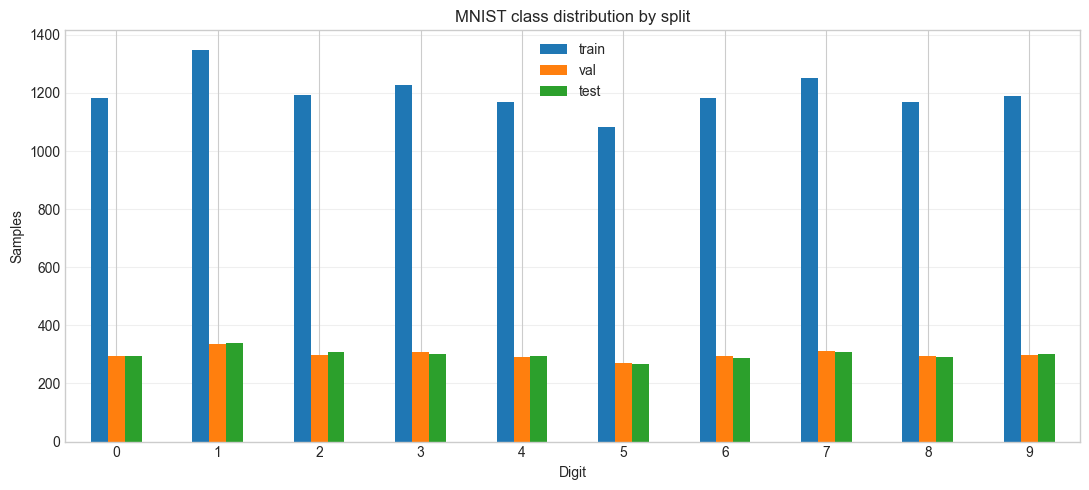

Saved D:\projects\MNIST ML project\Multiclass Classification\SVM\outputs\figures\svm_phase2_tuning_results.png


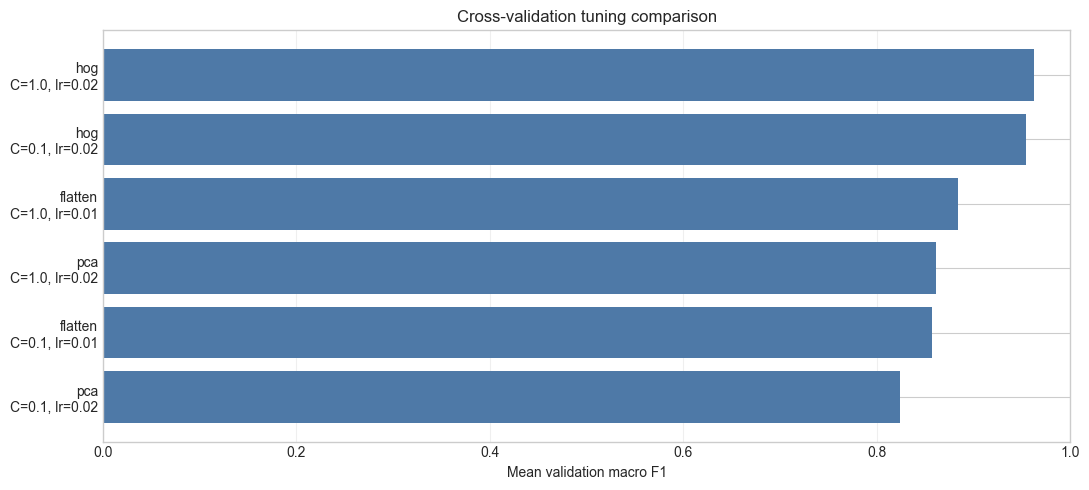

Saved D:\projects\MNIST ML project\Multiclass Classification\SVM\outputs\figures\svm_phase2_training_loss.png


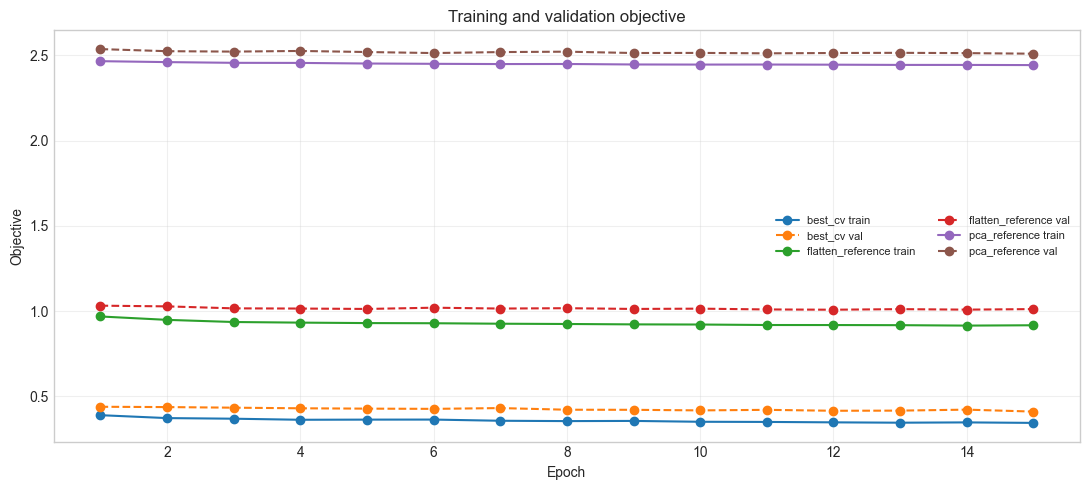

Saved D:\projects\MNIST ML project\Multiclass Classification\SVM\outputs\figures\svm_phase2_learning_curve.png


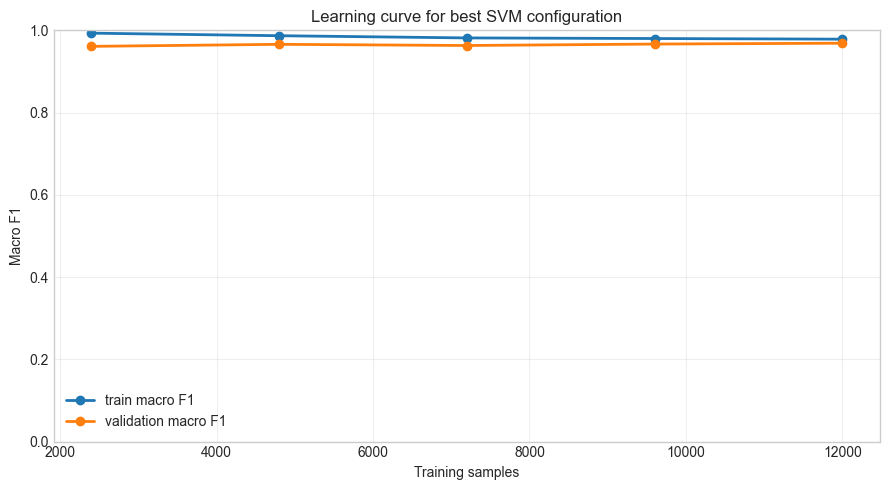

Saved D:\projects\MNIST ML project\Multiclass Classification\SVM\outputs\figures\svm_phase2_confusion_matrix.png


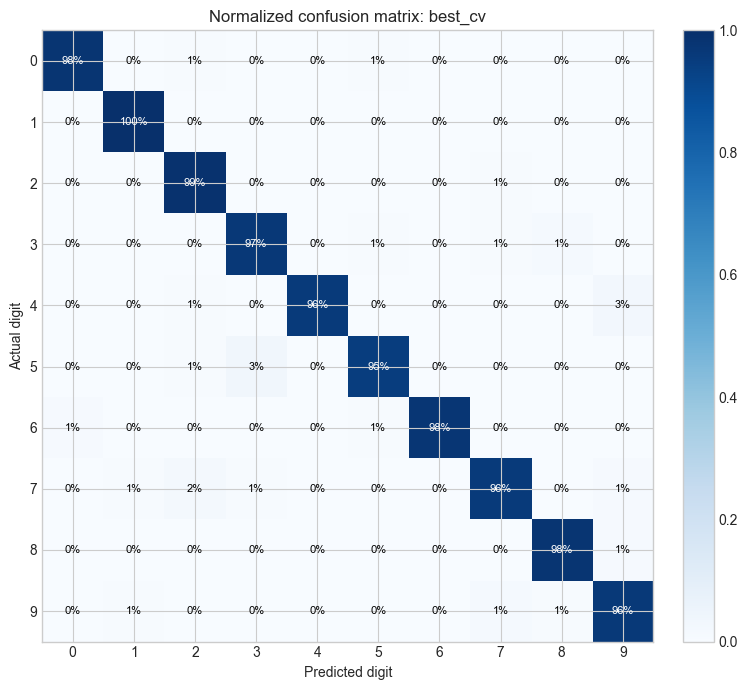

Saved D:\projects\MNIST ML project\Multiclass Classification\SVM\outputs\figures\svm_phase2_per_class_f1.png


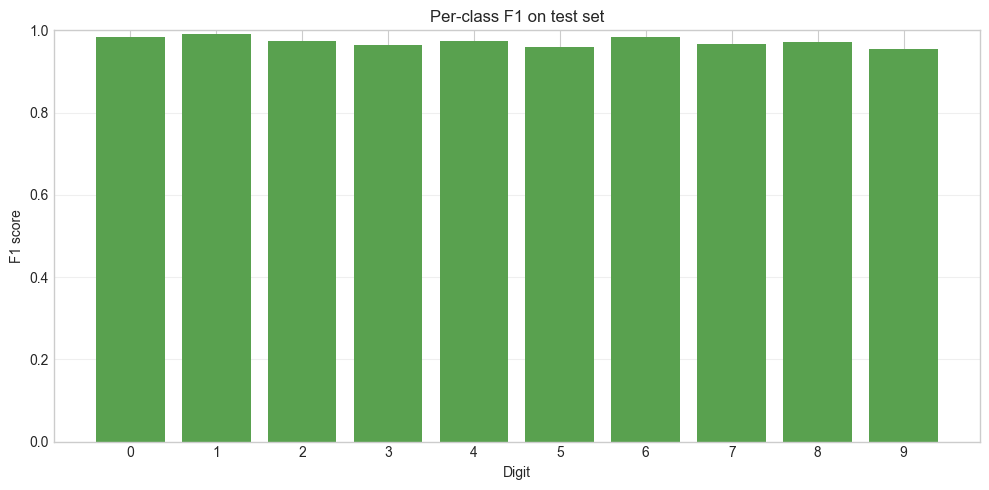

Saved D:\projects\MNIST ML project\Multiclass Classification\SVM\outputs\figures\svm_phase2_mistakes.png


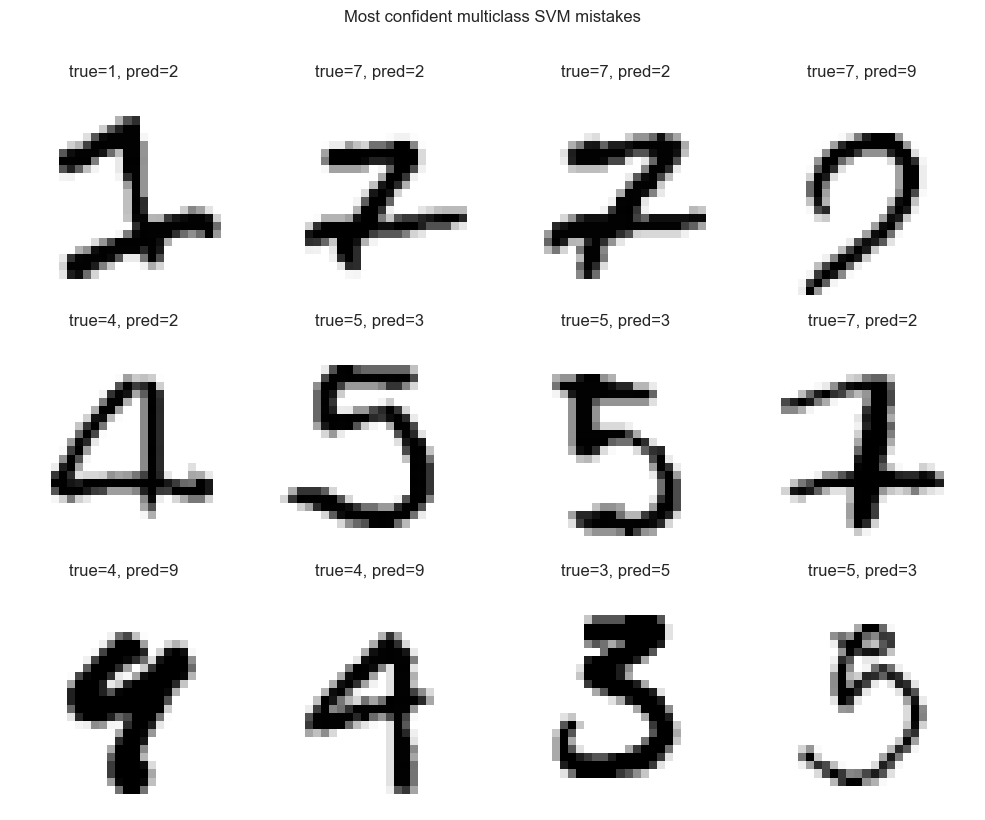

,precision,recall,f1-score,support
0,0.986301,0.979592,0.982935,294.0
1,0.985465,0.997059,0.991228,340.0
2,0.956386,0.990323,0.973059,310.0
3,0.960656,0.966997,0.963816,303.0
4,0.989510,0.959322,0.974182,295.0
5,0.973180,0.947761,0.960302,268.0
6,0.992908,0.975610,0.984183,287.0
7,0.973597,0.957792,0.965630,308.0
8,0.962963,0.979452,0.971138,292.0
9,0.944984,0.963696,0.954248,303.0


In [9]:
def save_current_figure(filename):
    path = FIGURE_DIR / filename
    plt.savefig(path, dpi=180, bbox_inches="tight")
    print(f"Saved {path}")


fig, ax = plt.subplots(figsize=(11, 5))
class_counts = pd.DataFrame({
    split_name: np.bincount(split_data[f"y_{split_name}"], minlength=10)
    for split_name in ("train", "val", "test")
}, index=CLASS_LABELS)
class_counts.plot(kind="bar", ax=ax)
ax.set_title("MNIST class distribution by split")
ax.set_xlabel("Digit")
ax.set_ylabel("Samples")
ax.tick_params(axis="x", rotation=0)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
save_current_figure("svm_phase2_class_distribution.png")
plt.show()

fig, ax = plt.subplots(figsize=(11, 5))
plot_cv = cv_results.sort_values("mean_val_macro_f1")
labels = [f"{row.feature_mode}\nC={row.C}, lr={row.lr}" for row in plot_cv.itertuples()]
ax.barh(labels, plot_cv["mean_val_macro_f1"], color="#4e79a7")
ax.set_title("Cross-validation tuning comparison")
ax.set_xlabel("Mean validation macro F1")
ax.set_xlim(0.0, 1.0)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
save_current_figure("svm_phase2_tuning_results.png")
plt.show()

fig, ax = plt.subplots(figsize=(11, 5))
for name, result in experiments.items():
    history = result["history"]
    ax.plot(history["epoch"], history["train_loss"], marker="o", label=f"{name} train")
    ax.plot(history["epoch"], history["val_loss"], linestyle="--", marker="o", label=f"{name} val")
ax.set_title("Training and validation objective")
ax.set_xlabel("Epoch")
ax.set_ylabel("Objective")
ax.grid(alpha=0.3)
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
save_current_figure("svm_phase2_training_loss.png")
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(learning_curve_table["train_samples"], learning_curve_table["train_macro_f1"], marker="o", linewidth=2, label="train macro F1")
ax.plot(learning_curve_table["train_samples"], learning_curve_table["val_macro_f1"], marker="o", linewidth=2, label="validation macro F1")
ax.set_title("Learning curve for best SVM configuration")
ax.set_xlabel("Training samples")
ax.set_ylabel("Macro F1")
ax.set_ylim(0.0, 1.0)
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
save_current_figure("svm_phase2_learning_curve.png")
plt.show()

best_cm = best_result["confusion_matrix"]
best_cm_norm = best_cm / best_cm.sum(axis=1, keepdims=True)
fig, ax = plt.subplots(figsize=(8, 7))
image = ax.imshow(best_cm_norm, cmap="Blues", vmin=0.0, vmax=1.0)
ax.set_title(f"Normalized confusion matrix: {best_name}")
ax.set_xlabel("Predicted digit")
ax.set_ylabel("Actual digit")
ax.set_xticks(CLASS_LABELS)
ax.set_yticks(CLASS_LABELS)
for (row, col), value in np.ndenumerate(best_cm_norm):
    text_color = "white" if value > 0.5 else "black"
    ax.text(col, row, f"{value:.0%}", ha="center", va="center", color=text_color, fontsize=8)
fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
save_current_figure("svm_phase2_confusion_matrix.png")
plt.show()

per_class_report = pd.DataFrame(classification_report(
    split_data["y_test"],
    best_result["predictions"]["test"],
    labels=CLASS_LABELS,
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0,
)).T
per_class_metrics = per_class_report.loc[CLASS_NAMES, ["precision", "recall", "f1-score", "support"]]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(per_class_metrics.index, per_class_metrics["f1-score"], color="#59a14f")
ax.set_title("Per-class F1 on test set")
ax.set_xlabel("Digit")
ax.set_ylabel("F1 score")
ax.set_ylim(0.0, 1.0)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
save_current_figure("svm_phase2_per_class_f1.png")
plt.show()

misclassified_idx = np.flatnonzero(split_data["y_test"] != best_result["predictions"]["test"])
if len(misclassified_idx) > 0:
    scores = best_result["model"].decision_function(best_result["features"]["x_test"])
    confidence = np.max(scores[misclassified_idx], axis=1)
    selected = misclassified_idx[np.argsort(confidence)[::-1]][:12]
else:
    selected = np.array([], dtype=int)

fig, axes = plt.subplots(3, 4, figsize=(10, 8))
fig.suptitle("Most confident multiclass SVM mistakes", y=1.02)
for ax, idx in zip(axes.ravel(), selected):
    ax.imshow(split_data["x_test"][idx], cmap="gray_r", vmin=0.0, vmax=1.0)
    actual = split_data["y_test"][idx]
    pred = best_result["predictions"]["test"][idx]
    ax.set_title(f"true={actual}, pred={pred}")
    ax.axis("off")
for ax in axes.ravel()[len(selected):]:
    ax.axis("off")
plt.tight_layout()
save_current_figure("svm_phase2_mistakes.png")
plt.show()

per_class_metrics


## Result Export

This cell writes CSV and JSON summaries beside the notebook. Re-run it after changing hyperparameters or rerunning experiments.


In [10]:
def save_result_exports():
    phase2_summary = comparison_table[[
        "name",
        "feature_mode",
        "feature_dimension",
        "C",
        "lr",
        "test_accuracy",
        "test_precision_macro",
        "test_recall_macro",
        "test_f1_macro",
        "test_f1_weighted",
    ]].copy()

    cv_export = cv_results[[
        "config_id",
        "feature_mode",
        "pca_components",
        "C",
        "lr",
        "mean_val_accuracy",
        "mean_val_macro_f1",
        "mean_val_weighted_f1",
    ]].copy()

    learning_export = learning_curve_table[[
        "train_fraction",
        "train_samples",
        "train_macro_f1",
        "val_macro_f1",
    ]].copy()

    per_class_export = per_class_metrics.reset_index().rename(columns={"index": "digit", "f1-score": "f1_score"})

    exports = {
        "svm_phase2_summary_table.csv": phase2_summary,
        "svm_phase2_cv_table.csv": cv_export,
        "svm_phase2_learning_table.csv": learning_export,
        "svm_phase2_per_class_table.csv": per_class_export,
    }

    for filename, frame in exports.items():
        path = TABLE_DIR / filename
        frame.to_csv(path, index=False)
        print(f"Saved {path}")

    best_test_report = best_result["reports"]["test"]
    summary_payload = {
        "best_model": best_name,
        "best_feature": best_result["config"]["feature_mode"],
        "test_accuracy": best_test_report["accuracy"],
        "test_macro_f1": best_test_report["f1_macro"],
        "test_weighted_f1": best_test_report["f1_weighted"],
        "config": best_result["config"],
    }
    summary_path = TABLE_DIR / "svm_phase2_summary.json"
    summary_path.write_text(pd.Series(summary_payload).to_json(indent=2), encoding="utf-8")
    print(f"Saved {summary_path}")


save_result_exports()

Saved D:\projects\MNIST ML project\Multiclass Classification\SVM\outputs\tables\svm_phase2_summary_table.csv
Saved D:\projects\MNIST ML project\Multiclass Classification\SVM\outputs\tables\svm_phase2_cv_table.csv
Saved D:\projects\MNIST ML project\Multiclass Classification\SVM\outputs\tables\svm_phase2_learning_table.csv
Saved D:\projects\MNIST ML project\Multiclass Classification\SVM\outputs\tables\svm_phase2_per_class_table.csv
Saved D:\projects\MNIST ML project\Multiclass Classification\SVM\outputs\tables\svm_phase2_summary.json


## Final Evaluation Summary

The final cell prints the selected configuration, final test metrics, and the raw confusion matrix for direct inspection.


In [11]:
best_test_report = best_result["reports"]["test"]
print(f"Best multiclass SVM experiment: {best_name}")
print(f"Configuration: {best_result['config']}")
print(
    "Test metrics -> "
    f"Accuracy: {best_test_report['accuracy']:.4f}, "
    f"Macro Precision: {best_test_report['precision_macro']:.4f}, "
    f"Macro Recall: {best_test_report['recall_macro']:.4f}, "
    f"Macro F1: {best_test_report['f1_macro']:.4f}, "
    f"Weighted F1: {best_test_report['f1_weighted']:.4f}"
)
print("\nConfusion matrix rows = actual digits, columns = predicted digits:")
print(pd.DataFrame(best_result["confusion_matrix"], index=CLASS_LABELS, columns=CLASS_LABELS).to_string())


Best multiclass SVM experiment: best_cv
Configuration: {'feature_mode': 'hog', 'C': 1.0, 'lr': 0.02, 'epochs': 15, 'batch_size': 256}
Test metrics -> Accuracy: 0.9723, Macro Precision: 0.9726, Macro Recall: 0.9718, Macro F1: 0.9721, Weighted F1: 0.9723

Confusion matrix rows = actual digits, columns = predicted digits:
     0    1    2    3    4    5    6    7    8    9
0  288    0    2    0    0    2    0    0    1    1
1    0  339    1    0    0    0    0    0    0    0
2    0    0  307    0    0    0    0    2    1    0
3    0    0    1  293    0    2    0    2    4    1
4    0    1    2    0  283    0    1    0    0    8
5    0    0    2    9    0  254    1    0    1    1
6    3    0    0    0    1    2  280    0    1    0
7    0    2    5    2    0    0    0  295    1    3
8    1    0    0    1    1    0    0    0  286    3
9    0    2    1    0    1    1    0    4    2  292


## Interpretation Notes and Code Improvements

The multiclass results show that HOG features are the most suitable representation for the manual Linear SVM in this setup. The learning curve also shows a small train-validation gap, which means the best model is not just memorizing the subset; adding more training samples may still help, but the representation is already doing useful work.

Code-level improvements made or recommended:

- The SVM class supports an explicit `num_classes` argument so smaller stratified subsets cannot accidentally shrink the output layer.
- Generated figures and tables now live under `Multiclass Classification/SVM/outputs`, keeping `reports` reserved for the final PDF.
- Future speed improvement: cache prepared feature matrices per feature mode so cross-validation does not recompute HOG descriptors repeatedly.
- Future evaluation improvement: add top-2 accuracy and inspect second-place scores for ambiguous digits such as 4/9 and 3/5.


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

def plot_multiclass_visuals(experiments):
    best_name = max(experiments, key=lambda k: experiments[k]['reports']['val']['f1_macro'])
    best_exp = experiments[best_name]
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # 1. Confusion Matrix Heatmap
    cm = best_exp['confusion_matrix']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0],
                xticklabels=CLASS_LABELS, yticklabels=CLASS_LABELS)
    axes[0].set_title(f"Confusion Matrix ({best_name})", fontsize=15)
    axes[0].set_xlabel('Predicted Digit', fontsize=12)
    axes[0].set_ylabel('True Digit', fontsize=12)
    
    # 2. Learning Curves
    history = pd.DataFrame(best_exp['history'])
    axes[1].plot(history['epoch'], history['train_loss'], label='Train Loss', marker='o', linewidth=2)
    if 'val_loss' in history.columns:
        axes[1].plot(history['epoch'], history['val_loss'], label='Val Loss', marker='s', linewidth=2)
    axes[1].set_title('Learning Curve (Adam + Early Stopping)', fontsize=15)
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Crammer-Singer Hinge Loss', fontsize=12)
    axes[1].legend(fontsize=12)
    axes[1].grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "multiclass_svm_visuals.png", dpi=300, bbox_inches='tight')
    plt.show()

plot_multiclass_visuals(experiments)